# Netflix Data Analysis Notebook

This project explores the Netflix Movies and TV Shows to uncover insights into the type of content available on Netflix. The main objective is to analyze trends in movies and TV shows, identify the top contributing countries, examine the most common genres, and understand how Netflix’s content library has grown over time.

Using Python and data analysis libraries such as Pandas, Matplotlib, and Seaborn, the dataset is first cleaned and prepared to handle missing values and inconsistencies. Exploratory Data Analysis (EDA) is then performed to answer key business questions and reveal patterns within the data.

The insights from this analysis aim to demonstrate practical data analysis skills, including data cleaning, transformation, visualization, and storytelling, which are essential for making data-driven decisions.

### Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


### Loading the Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Understanding data

In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


# Data Cleaning

In [5]:
df.isnull().sum() #check missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Handling missing values

In [6]:
df['country'] = df['country'].fillna('unknown') # replacing missing countries with unknown
df['cast'] = df['cast'].fillna('unknown') #filling missing casts with unknown
df['director'] = df['director'].fillna('unknown') #filling missing directors with unknown
df['rating'] = df['rating'].fillna('unknown') #filling missing rating with unknown

### Check unique values

In [7]:
df.nunique() #check unique values

show_id         8807
type               2
title           8807
director        4529
cast            7693
country          749
date_added      1767
release_year      74
rating            18
duration         220
listed_in        514
description     8775
dtype: int64

### Check duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

### Clean date_added column

In [9]:
df['date_added'] = df['date_added'].str.strip() #remove extra space in date_added
df['date_added'] = pd.to_datetime(df['date_added']) #convert date_added to datetime format
df['year_added'] = df['date_added'].dt.year # add new column year_added from date_added

### Extract year and month 

In [10]:
df = df.dropna(subset=['date_added']) #drop missing rows in date_added ,10
df['year_added'] = df['date_added'].dt.year #extract year
df['month_added']=df['date_added'].dt.month #extract month
df['year_added'].astype(int) # chnange year_added to int
df['month_added'].astype(int) # chnange month_added to int

0        9
1        9
2        9
3        9
4        9
        ..
8802    11
8803     7
8804    11
8805     1
8806     3
Name: month_added, Length: 8797, dtype: int64

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


### Clean Duration

In [12]:
df[['duration_num', 'duration_type']] = df['duration'].str.split(' ', expand=True)

## Data Visualization

Movies vs TV Shows

In [13]:
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

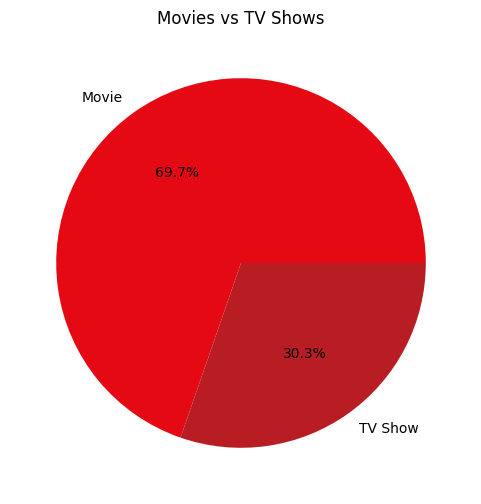

In [14]:
my_colors = ['#E50914', '#B81D24']
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors = my_colors)
fig = plt.gcf()
fig.set_size_inches(6,6)
plt.title('Movies vs TV Shows')
plt.show()

### Top Countries

In [15]:
df['country'] = df['country'].str.split(',') #split countries
df_exploded = df.explode('country') #exploid into multiple rows
df_exploded['country'] = df_exploded['country'].str.strip()
df_exploded = df_exploded[df_exploded['country'] != 'unknown']
df_exploded['country'].value_counts().head(10)

country
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

<Axes: title={'center': 'Top 10 Countries'}, xlabel='country'>

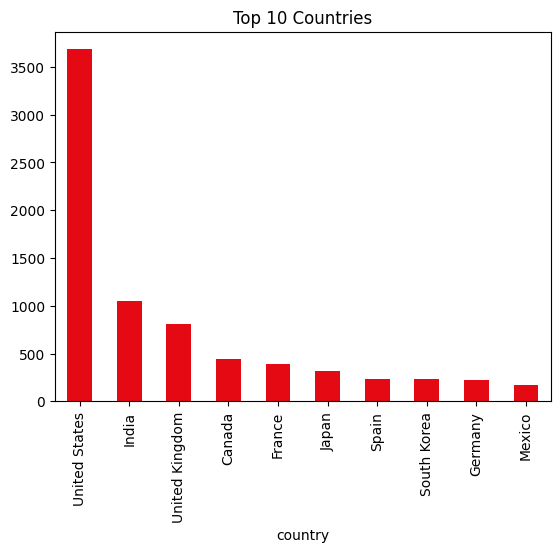

In [16]:
df_exploded['country'].value_counts().head(10).plot(kind='bar', title='Top 10 Countries', color = '#E50914')

## Top Genres

<Axes: title={'center': 'Top 10 Genres'}, xlabel='listed_in'>

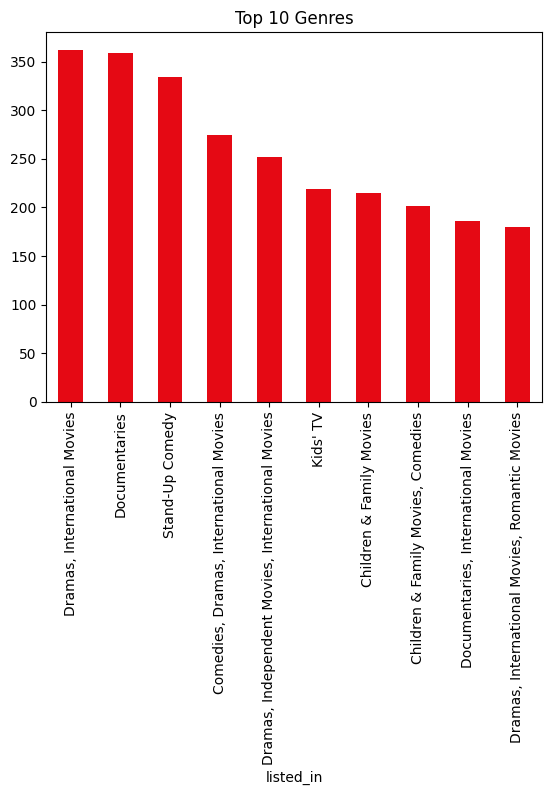

In [17]:
df['listed_in'].value_counts().head(10).plot(kind='bar', title='Top 10 Genres', color = '#E50914')

### Growth Over Time

<Axes: title={'center': 'Type count over years'}, xlabel='year_added'>

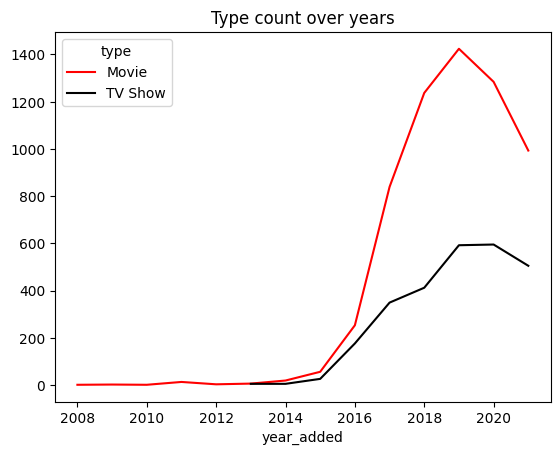

In [18]:
df.groupby(['year_added', 'type']).size().unstack().plot(title='Type count over years', color = ['red', 'black'])

### TV Shows and Movie Ratings

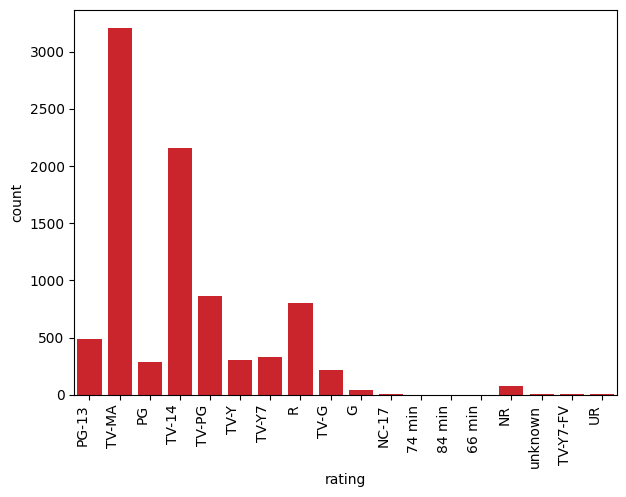

In [20]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='rating', data=df, color = '#E50914')

plt.xticks(rotation=90, ha='right')
plt.show()

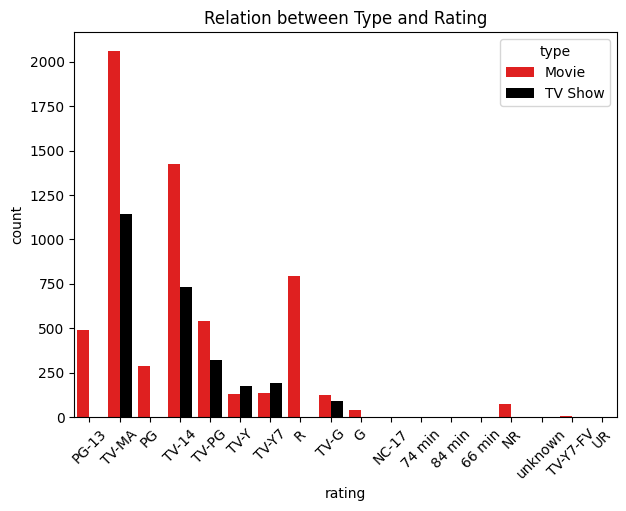

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(x='rating', hue='type', data=df, palette=['red', 'black'])

plt.title('Relation between Type and Rating')
plt.xticks(rotation=45)
plt.show()

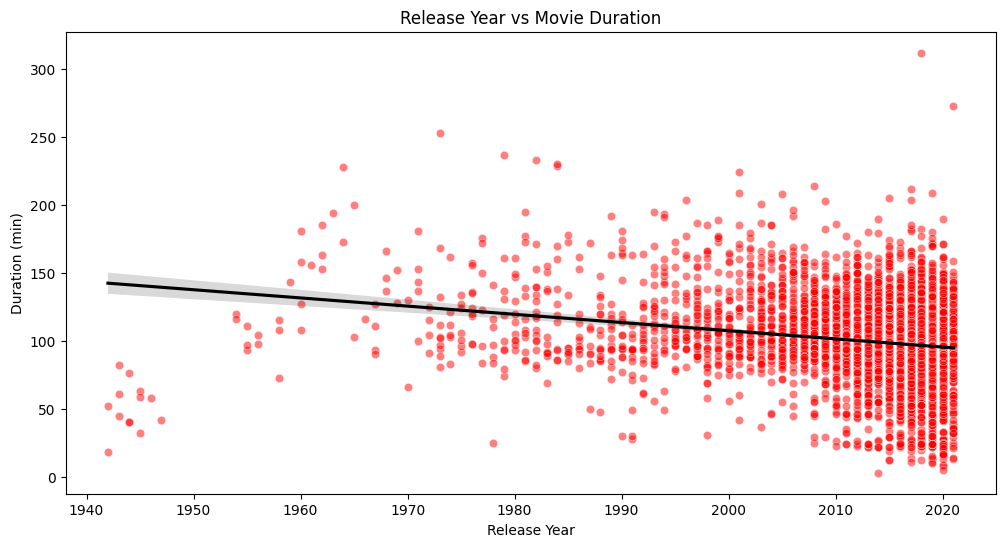

In [22]:
movies = df[df['type'] == 'Movie'].copy()

# Clean duration
movies['duration'] = movies['duration'].str.replace(' min', '')
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Plot
plt.figure(figsize=(12,6))
sns.scatterplot(
    x='release_year',
    y='duration',
    data=movies,
    color='red',
    alpha=0.5
)
sns.regplot(
    x='release_year',
    y='duration',
    data=movies,
    scatter=False,
    color='black'
)

plt.title('Release Year vs Movie Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (min)')
plt.show()

## Key Insights

- Movies dominate Netflix content
- USA produces the most content
- Drama is the most common genre
- Content growth peaked between 2018–2020